# Pandas Practice 2

![IRIS, https://github.com/simonava5/fishers-iris-data](./images/iris.png)

After the notebook with a lot of new input, let's start applying it totally by yourselves. 
For this purpose we will use one of the most standard real-life datasets: Its called Iris Dataset, and is all about the plant iris. Let's learn a little bit more about the dataset by looking at it. 

## Learning Objectives





By the end of this notebook, you will feel more comfortable with your newly acquired knowledge, as you will see that you can

- load data from csv files into DataFrames
- access data stored in DataFrames
- use the general functions of a DataFrame to answer questions about the data
- create insightful plots using the pandas function `.plot()`
- explain what conclusions you draw from these visualizations.


In [4]:
# import pandas
import pandas as pd

In [5]:
# load the data
df = pd.read_csv('data/iris.csv')

Let us first have a look at the head of the table, maybe also on the last 10 rows...

In [6]:
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
df.tail(10)

,sepal_length,sepal_width,petal_length,petal_width,species
140,6.7,3.1,5.6,2.4,Iris-virginica
141,6.9,3.1,5.1,2.3,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica
143,6.8,3.2,5.9,2.3,Iris-virginica
144,6.7,3.3,5.7,2.5,Iris-virginica
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


How many irises are in the data set?

In [8]:
df.species.groupby(df.species).count()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: species, dtype: int64

How many different species are there?

In [9]:
df.species.groupby(df.species).count().count()

np.int64(3)

Calculate the mean, median, mode for petal length

In [44]:
mean_ = df["petal_length"].mean() 
print("mean petal length:", mean_)

mean petal length: 3.758666666666666


In [46]:
median_ = df["petal_length"].median()
print("median petal length:", median_)

median petal length: 4.35


In [49]:
mode_ = df["petal_length"].mode().values[0]
print("mode petal length:", mode_)

mode petal length: 1.5


What can you conclude about the distribution for petal length?

In [41]:
if mean_ < median_:
    print("The distribution is likely left-skewed (negatively skewed).")
elif mean_ > median_:
    print("The distribution is likely right-skewed (positively skewed).")
else:
    print("The distribution may be symmetric.")

The distribution is likely left-skewed (negatively skewed).


What is the smallest and largest value for petal length?

In [52]:
petal_length_lowest = df.petal_length.sort_values(ascending=True).head(1).values[0]
print("lowest petal length:", petal_length_lowest)


lowest petal length: 1.0


In [53]:
petal_length_highest = df.petal_length.sort_values(ascending=False).head(1).values[0]
print("highest petal length:", petal_length_highest)

highest petal length: 6.9


Calculate the variance and standard deviation for petal length

In [56]:
variance_ = df.petal_length.var()
deviation_ = df.petal_length.std()
print("variance petal length:", variance_)
print("standard deviation petal length:", deviation_)

variance petal length: 3.113179418344519
standard deviation petal length: 1.7644204199522626


Calculate the basic descriptive statistics for all columns of the iris data set with a single command.

In [58]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


What is the overall average for sepal length?

In [62]:
df.sepal_length.mean()

np.float64(5.843333333333334)

Use the DataFrame grouping function to determine the count by species.

In [63]:
df.species.groupby(df.species).count()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: species, dtype: int64

Use the DataFrame grouping function to determine the average length and width of sepals and pedals by species.

In [68]:
df.groupby(df.species).mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


Add the sum of the sepal width and length as a new column to your DataFrame.

In [70]:
df.eval('sepal_sum = `sepal_length` + `sepal_width`', inplace = True)
df 

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_sum
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica,9.7
146,6.3,2.5,5.0,1.9,Iris-virginica,8.8
147,6.5,3.0,5.2,2.0,Iris-virginica,9.5
148,6.2,3.4,5.4,2.3,Iris-virginica,9.6


Visualize petal length with a histogram

array([[<Axes: title={'center': 'petal_length'}>]], dtype=object)

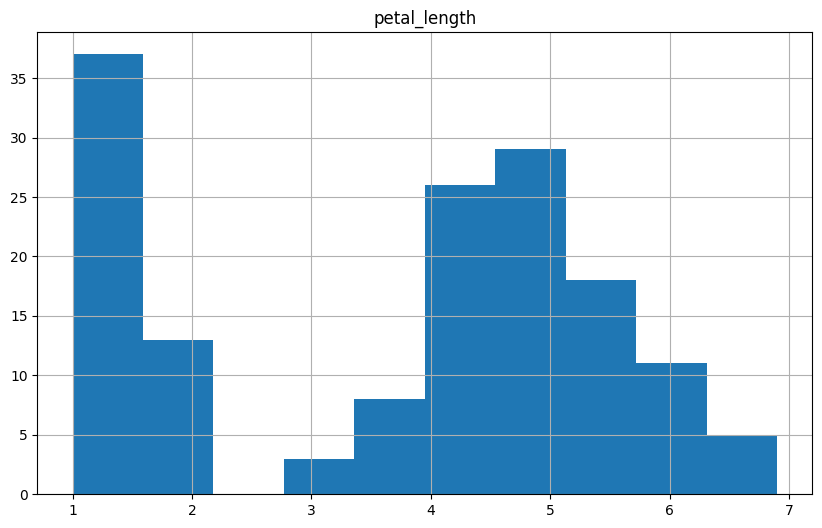

In [93]:
df.hist(column='petal_length',  bins=10, figsize=(10, 6))

Describe the distribution

In [94]:
df.petal_length.describe()

count    150.000000
mean       3.758667
std        1.764420
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: petal_length, dtype: float64

Which is more informative: the summary statistics or visualizations?

the visualization

Visualize petal length and width with a "scatter_matrix"

array([[<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>]], dtype=object)

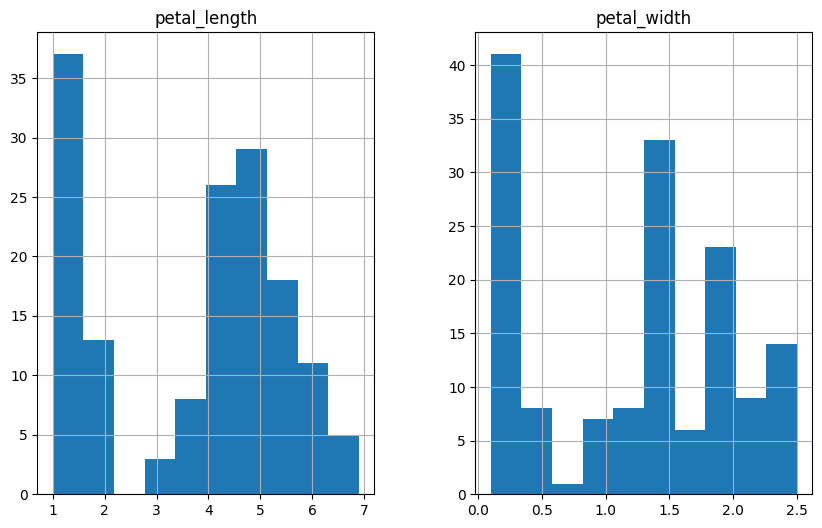

In [109]:
df.hist(column=['petal_length', 'petal_width'], bins=10, figsize=(10, 6))

Create a new column with a rough estimate of petal area by multiplying petal length and width together.

In [111]:
df.eval('petal_area = `petal_length` * `petal_width`', inplace = True)
df

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_sum,petal_area
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6,0.28
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9,0.28
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9,0.26
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7,0.30
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6,0.28
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica,9.7,11.96
146,6.3,2.5,5.0,1.9,Iris-virginica,8.8,9.50
147,6.5,3.0,5.2,2.0,Iris-virginica,9.5,10.40
148,6.2,3.4,5.4,2.3,Iris-virginica,9.6,12.42


Create a new DataFrame with petal areas greater than $1cm^2$.

In [113]:
df[df['petal_area'] > 1] 

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_sum,petal_area
50,7.0,3.2,4.7,1.4,Iris-versicolor,10.2,6.58
51,6.4,3.2,4.5,1.5,Iris-versicolor,9.6,6.75
52,6.9,3.1,4.9,1.5,Iris-versicolor,10.0,7.35
53,5.5,2.3,4.0,1.3,Iris-versicolor,7.8,5.20
54,6.5,2.8,4.6,1.5,Iris-versicolor,9.3,6.90
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica,9.7,11.96
146,6.3,2.5,5.0,1.9,Iris-virginica,8.8,9.50
147,6.5,3.0,5.2,2.0,Iris-virginica,9.5,10.40
148,6.2,3.4,5.4,2.3,Iris-virginica,9.6,12.42


Create 3 new DataFrames, one for each species. Use the entire dataset.

In [118]:
setosa = df[df.species == 'Iris-setosa']
versicolor = df[df.species == 'Iris-versicolor']
virginica = df[df.species == 'Iris-virginica']

In [120]:
setosa.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_sum,petal_area
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6,0.28
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9,0.28
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9,0.26
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7,0.30
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6,0.28


In [ ]:
versicolor.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_sum,petal_area
50,7.0,3.2,4.7,1.4,Iris-versicolor,10.2,6.58
51,6.4,3.2,4.5,1.5,Iris-versicolor,9.6,6.75
52,6.9,3.1,4.9,1.5,Iris-versicolor,10.0,7.35
53,5.5,2.3,4.0,1.3,Iris-versicolor,7.8,5.20
54,6.5,2.8,4.6,1.5,Iris-versicolor,9.3,6.90


In [121]:
virginica

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_sum,petal_area
100,6.3,3.3,6.0,2.5,Iris-virginica,9.6,15.00
101,5.8,2.7,5.1,1.9,Iris-virginica,8.5,9.69
102,7.1,3.0,5.9,2.1,Iris-virginica,10.1,12.39
103,6.3,2.9,5.6,1.8,Iris-virginica,9.2,10.08
104,6.5,3.0,5.8,2.2,Iris-virginica,9.5,12.76
105,7.6,3.0,6.6,2.1,Iris-virginica,10.6,13.86
106,4.9,2.5,4.5,1.7,Iris-virginica,7.4,7.65
107,7.3,2.9,6.3,1.8,Iris-virginica,10.2,11.34
108,6.7,2.5,5.8,1.8,Iris-virginica,9.2,10.44
109,7.2,3.6,6.1,2.5,Iris-virginica,10.8,15.25
